📊 DATASET OVERVIEW

Shape: (15000, 15)

Date Range: 2021-01-01 00:00:00 → 2023-12-31 00:00:00

📌 Column Types:
transaction_id            object
date              datetime64[ns]
year                       int64
quarter                   object
month                      int64
month_name                object
region                    object
category                  object
channel                   object
customer_id               object
unit_price               float64
quantity                   int64
revenue                  float64
cost                     float64
profit                   float64
dtype: object

📌 Missing Values:
transaction_id    0
date              0
year              0
quarter           0
month             0
month_name        0
region            0
category          0
channel           0
customer_id       0
unit_price        0
quantity          0
revenue           0
cost              0
profit            0
dtype: int64

📈 DESCRIPTIVE STATISTICS
          revenue     

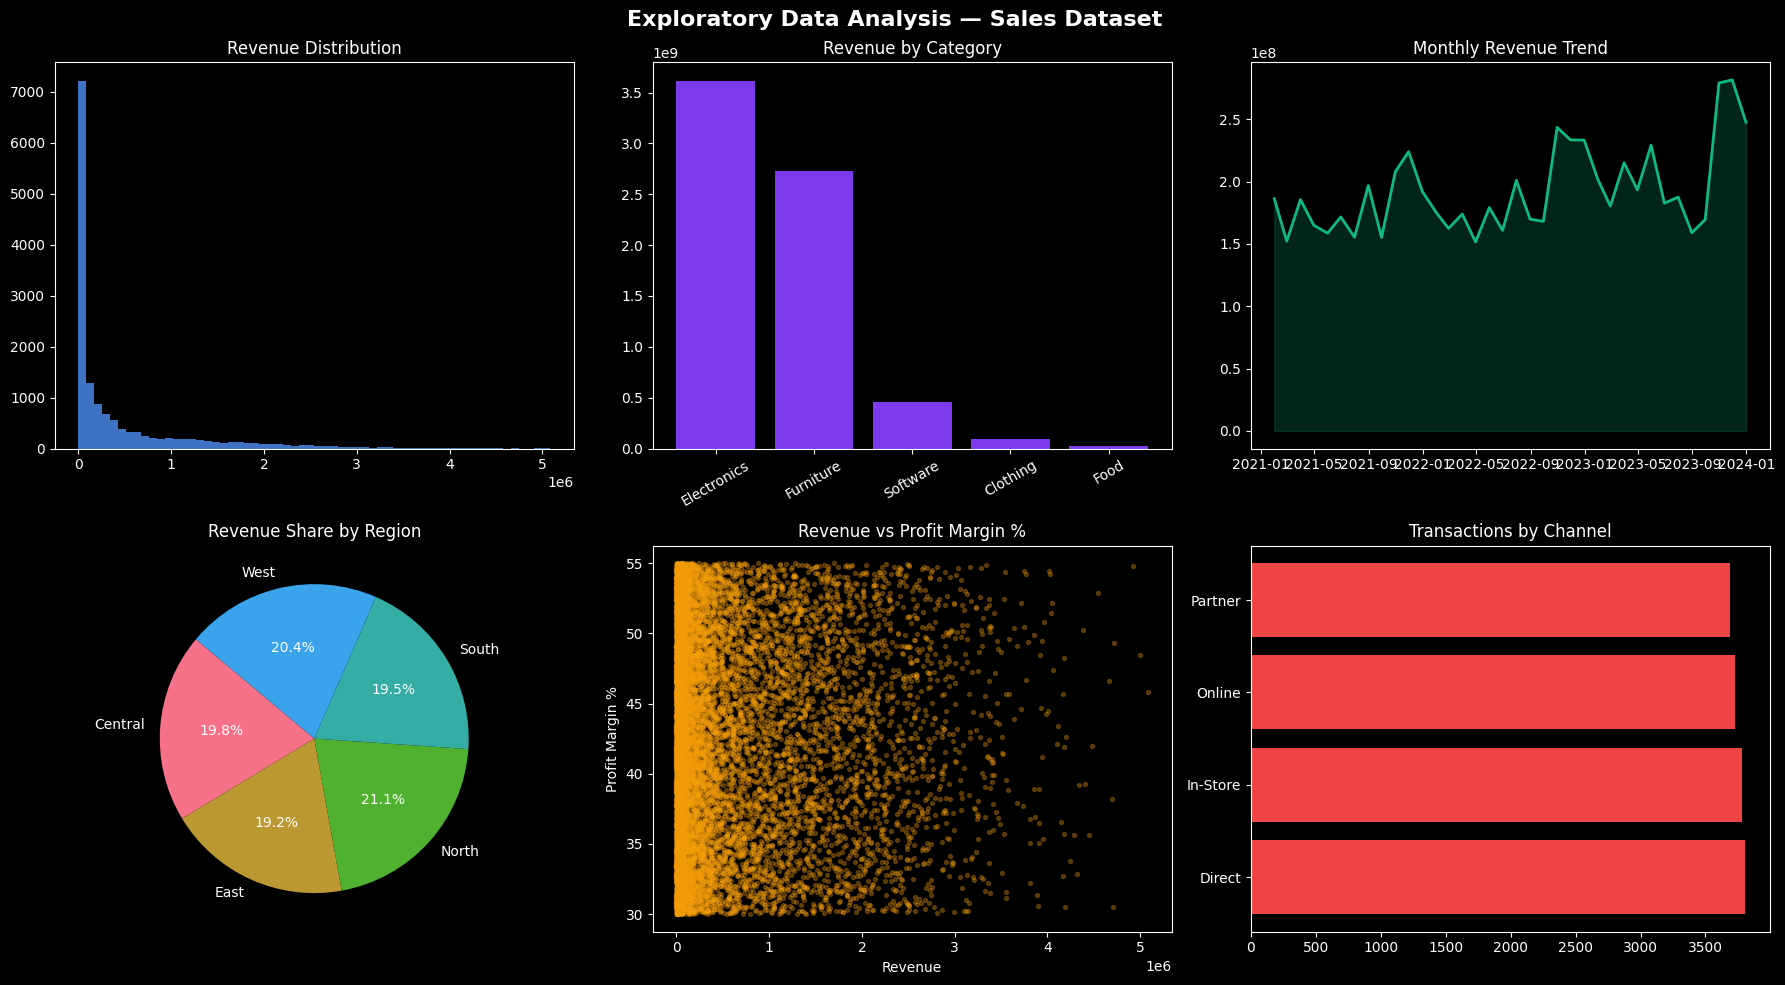


✅ EDA COMPLETED SUCCESSFULLY

📁 Files Saved:
1. ../assets/screenshots/eda.png
2. ../data/processed/sales_clean.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# ── SETTINGS ─────────────────────────────────────────────
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette('husl')

# ── LOAD DATA ────────────────────────────────────────────
df = pd.read_csv(
    "../data/raw/sales_data.csv",
    parse_dates=['date']
)

# ── DATASET OVERVIEW ─────────────────────────────────────
print("=" * 50)
print("📊 DATASET OVERVIEW")
print("=" * 50)

print(f"\nShape: {df.shape}")

print(
    f"\nDate Range: "
    f"{df['date'].min()} → {df['date'].max()}"
)

print("\n📌 Column Types:")
print(df.dtypes)

print("\n📌 Missing Values:")
print(df.isnull().sum())

# ── DESCRIPTIVE STATISTICS ───────────────────────────────
print("\n" + "=" * 50)
print("📈 DESCRIPTIVE STATISTICS")
print("=" * 50)

print(
    df[['revenue', 'cost', 'profit', 'quantity']]
    .describe()
    .round(2)
)

# ── CREATE NEW COLUMN ────────────────────────────────────
df['margin'] = (
    df['profit'] / df['revenue'] * 100
).round(2)

# ── CREATE FOLDERS ───────────────────────────────────────
os.makedirs("../assets/screenshots", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

# ── VISUALIZATIONS ───────────────────────────────────────
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

fig.suptitle(
    'Exploratory Data Analysis — Sales Dataset',
    fontsize=16,
    fontweight='bold'
)

# ── 1. Revenue Distribution ──────────────────────────────
axes[0, 0].hist(
    df['revenue'],
    bins=60,
    color='#4f8ef7',
    alpha=0.8
)

axes[0, 0].set_title('Revenue Distribution')

# ── 2. Revenue by Category ───────────────────────────────
cat_rev = (
    df.groupby('category')['revenue']
    .sum()
    .sort_values(ascending=False)
)

axes[0, 1].bar(
    cat_rev.index,
    cat_rev.values,
    color='#7c3aed'
)

axes[0, 1].set_title('Revenue by Category')

axes[0, 1].tick_params(
    axis='x',
    rotation=30
)

# ── 3. Monthly Revenue Trend ─────────────────────────────
monthly = (
    df.groupby(
        pd.Grouper(key='date', freq='M')
    )['revenue']
    .sum()
)

axes[0, 2].plot(
    monthly.index,
    monthly.values,
    color='#10b981',
    linewidth=2
)

axes[0, 2].fill_between(
    monthly.index,
    monthly.values,
    alpha=0.2,
    color='#10b981'
)

axes[0, 2].set_title('Monthly Revenue Trend')

# ── 4. Revenue Share by Region ───────────────────────────
reg_rev = (
    df.groupby('region')['revenue']
    .sum()
)

axes[1, 0].pie(
    reg_rev,
    labels=reg_rev.index,
    autopct='%1.1f%%',
    startangle=140
)

axes[1, 0].set_title('Revenue Share by Region')

# ── 5. Revenue vs Profit Margin ──────────────────────────
axes[1, 1].scatter(
    df['revenue'],
    df['margin'],
    alpha=0.3,
    s=8,
    color='#f59e0b'
)

axes[1, 1].set_title('Revenue vs Profit Margin %')

axes[1, 1].set_xlabel('Revenue')

axes[1, 1].set_ylabel('Profit Margin %')

# ── 6. Transactions by Channel ───────────────────────────
ch_count = df['channel'].value_counts()

axes[1, 2].barh(
    ch_count.index,
    ch_count.values,
    color='#ef4444'
)

axes[1, 2].set_title('Transactions by Channel')

# ── LAYOUT ───────────────────────────────────────────────
plt.tight_layout()

# ── SAVE CHART ───────────────────────────────────────────
plt.savefig(
    '../assets/screenshots/eda.png',
    dpi=150,
    bbox_inches='tight'
)

# ── SHOW PLOT ────────────────────────────────────────────
plt.show()

# ── SAVE CLEANED DATA ────────────────────────────────────
df.to_csv(
    '../data/processed/sales_clean.csv',
    index=False
)

# ── SUCCESS MESSAGE ──────────────────────────────────────
print("\n" + "=" * 50)
print("✅ EDA COMPLETED SUCCESSFULLY")
print("=" * 50)

print("\n📁 Files Saved:")

print(
    "1. ../assets/screenshots/eda.png"
)

print(
    "2. ../data/processed/sales_clean.csv"
)